# EduCasual Final Project Analysis

## Clear Question

**Does an increase in online engagement prior to an assessment cause an increase in student performance on that assessment?**

This notebook is the presentation layer. The data processing, variable definitions, model estimation, and plotting functions all live in `src/educasual/`.

In [4]:
from pathlib import Path
import sys

import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_PATH = PROJECT_ROOT / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

from educasual.config import ProjectPaths, load_analysis_config
from educasual.pipeline import build_panel_dataset
from educasual.models.fixed_effects import collect_model_summaries
from educasual.models.robustness import run_model_suite
from educasual.reporting import make_display_summary, pretty_variable_name
from educasual.visualization.plots import (
    plot_click_distribution,
    plot_decile_relationship,
    plot_heterogeneity_relationship,
)

paths = ProjectPaths()
config = load_analysis_config()

## Clean Panel Dataset

If the processed panel already exists, we load it. Otherwise, we build it from the raw OULAD CSV files in `data/raw/oulad/`.

In [5]:
panel_path = paths.processed_data / "student_assessment_panel.csv"
if panel_path.exists():
    panel = pd.read_csv(panel_path)
else:
    panel = build_panel_dataset(paths.raw_data, panel_path)

panel.head()

,id_assessment,id_student,date_submitted,is_banked,score,code_module,code_presentation,assessment_type,date,weight,...,is_low_ses,is_repeat_student,has_disability,is_female,days_since_course_start,days_since_registration,days_until_unregistration,relative_progress,late_submission_days,cumulative_log_clicks
0,34873,100064,40,0,92.0,FFF,2013J,TMA,19.0,12.5,...,1,0,0,1,19.0,155.0,NaN,0.070896,21.0,6.023448
1,34874,100064,47,0,92.0,FFF,2013J,TMA,47.0,12.5,...,1,0,0,1,47.0,183.0,NaN,0.175373,0.0,6.731018
2,34875,100064,109,0,94.0,FFF,2013J,TMA,96.0,25.0,...,1,0,0,1,96.0,232.0,NaN,0.358209,13.0,7.546446
3,34876,100064,131,0,93.0,FFF,2013J,TMA,131.0,25.0,...,1,0,0,1,131.0,267.0,NaN,0.488806,0.0,8.033009
4,34877,100064,172,0,89.0,FFF,2013J,TMA,173.0,25.0,...,1,0,0,1,173.0,309.0,NaN,0.645522,-1.0,8.415603


In [6]:
panel.rename(
    columns={
        "log_clicks_28d": pretty_variable_name("log_clicks_28d"),
        "is_low_ses": pretty_variable_name("is_low_ses"),
        "is_repeat_student": pretty_variable_name("is_repeat_student"),
    }
)[
    [
        "student_course_id",
        "id_assessment",
        "score",
        pretty_variable_name("log_clicks_28d"),
        pretty_variable_name("is_low_ses"),
        pretty_variable_name("is_repeat_student"),
    ]
].describe(
    include="all"
)

,student_course_id,id_assessment,score,Pre-assessment engagement (log(1 + clicks in previous 28 days)),Lower socioeconomic background,Repeat student
count,171241,171241.000000,171241.000000,171241.000000,171241.000000,171241.000000
unique,23322,NaN,NaN,NaN,NaN,NaN
top,103904::DDD::2013B,NaN,NaN,NaN,NaN,NaN
freq,14,NaN,NaN,NaN,NaN,NaN
mean,NaN,26564.166917,76.028241,4.849751,0.393866,0.115486
std,NaN,8841.661440,18.590980,1.487796,0.488607,0.319609
min,NaN,1752.000000,0.000000,0.000000,0.000000,0.000000
25%,NaN,15022.000000,66.000000,4.110874,0.000000,0.000000
50%,NaN,25360.000000,80.000000,5.043425,0.000000,0.000000
75%,NaN,34883.000000,90.000000,5.894403,1.000000,0.000000


## Main Fixed-Effects Model And Extensions

In [7]:
results = run_model_suite(panel, config)
summary = collect_model_summaries(results)
make_display_summary(summary).sort_values(["model", "variable"]).reset_index(drop=True)

,model,model_code,variable,variable_code,coef,std_error,p_value,nobs,rsquared_within
0,Main FE model,main_fe,Pre-assessment engagement (log(1 + clicks in p...,log_clicks_28d,1.219222,0.052938,0.000000,171241.0,0.016269
1,Nonlinear FE model,nonlinear_fe,Pre-assessment engagement (log(1 + clicks in p...,log_clicks_28d,-0.228599,0.144420,0.113452,171241.0,0.020068
2,Nonlinear FE model,nonlinear_fe,Pre-assessment engagement squared ((log(1 + cl...,log_clicks_28d_sq,0.201519,0.018512,0.000000,171241.0,0.020068
3,Robustness: 14-day window,alt_window_14d,Pre-assessment engagement (log(1 + clicks in p...,log_clicks_14d,0.921654,0.043516,0.000000,171241.0,0.012049
4,Robustness: coursework only,coursework_only,Pre-assessment engagement (log(1 + clicks in p...,log_clicks_28d,1.177808,0.054961,0.000000,166286.0,0.014197
5,Robustness: cumulative engagement,alt_cumulative,Cumulative engagement (log(1 + cumulative clic...,cumulative_log_clicks,2.696256,0.165454,0.000000,171241.0,-0.013106
6,Robustness: non-banked only,clean_non_banked,Pre-assessment engagement (log(1 + clicks in p...,log_clicks_28d,1.266781,0.054223,0.000000,169366.0,0.017198
7,Subgroup: gender,heterogeneity_is_female,Pre-assessment engagement (log(1 + clicks in p...,log_clicks_28d,1.250345,0.068380,0.000000,171241.0,0.016218
8,Subgroup: gender,heterogeneity_is_female,Pre-assessment engagement (log(1 + clicks in p...,log_clicks_28d_x_is_female,-0.074030,0.098991,0.454558,171241.0,0.016218
9,Subgroup: lower SES,heterogeneity_is_low_ses,Pre-assessment engagement (log(1 + clicks in p...,log_clicks_28d,1.234428,0.067338,0.000000,171241.0,0.016281


## Figures

Recommended final presentation:

1. distribution of pre-assessment engagement
2. main relationship using `Pre-assessment engagement (log(1 + clicks in previous 28 days))`
3. subgroup comparison for lower-SES students
4. subgroup comparison for gender
5. model table including non-banked and coursework-only robustness

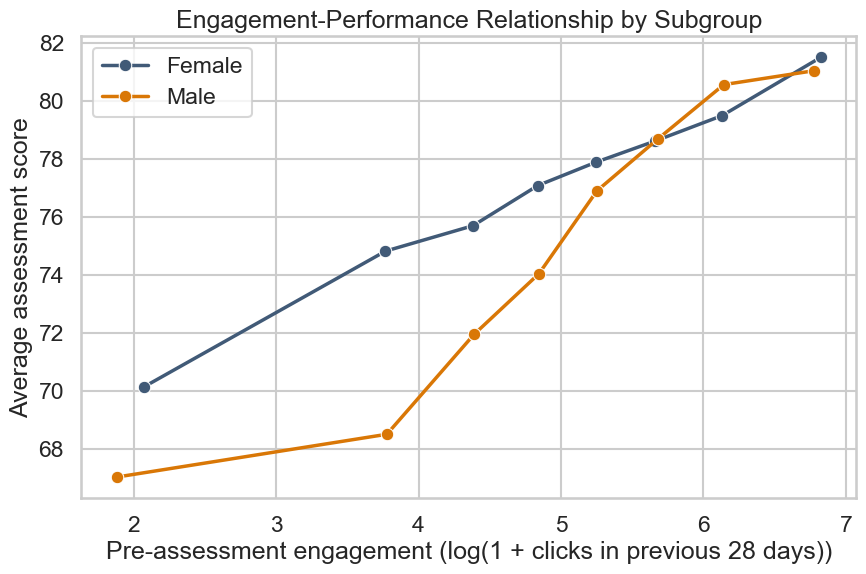

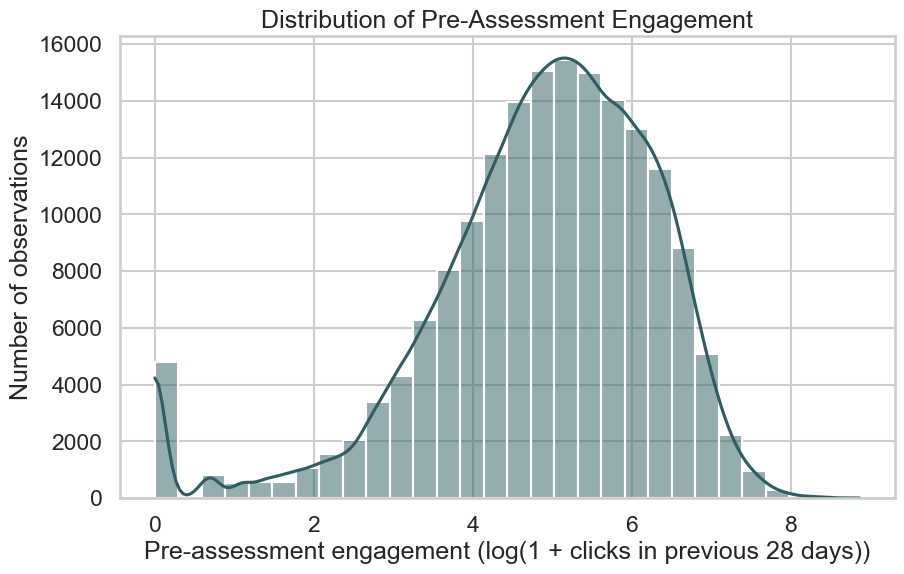

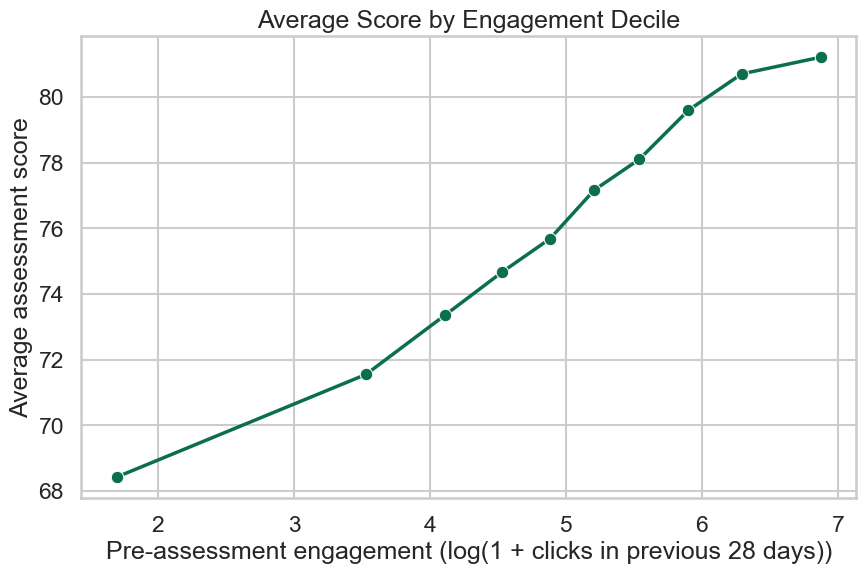

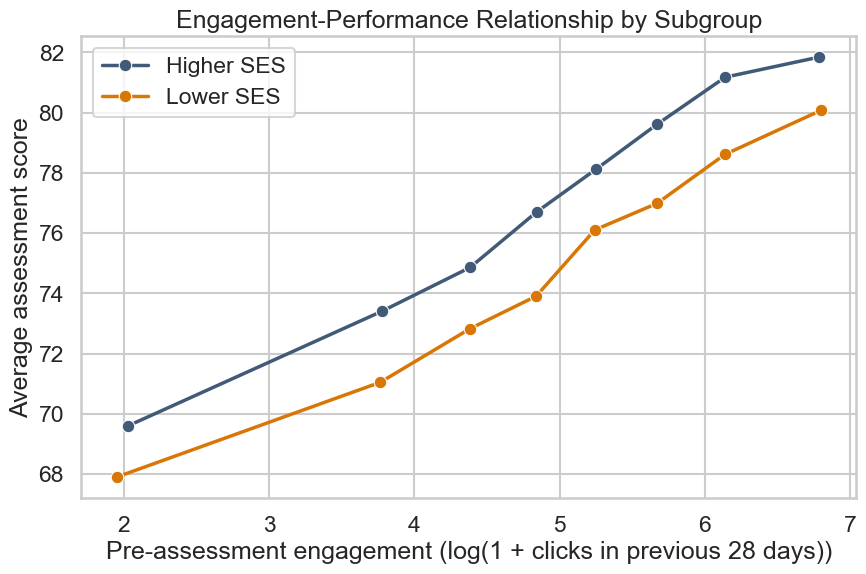

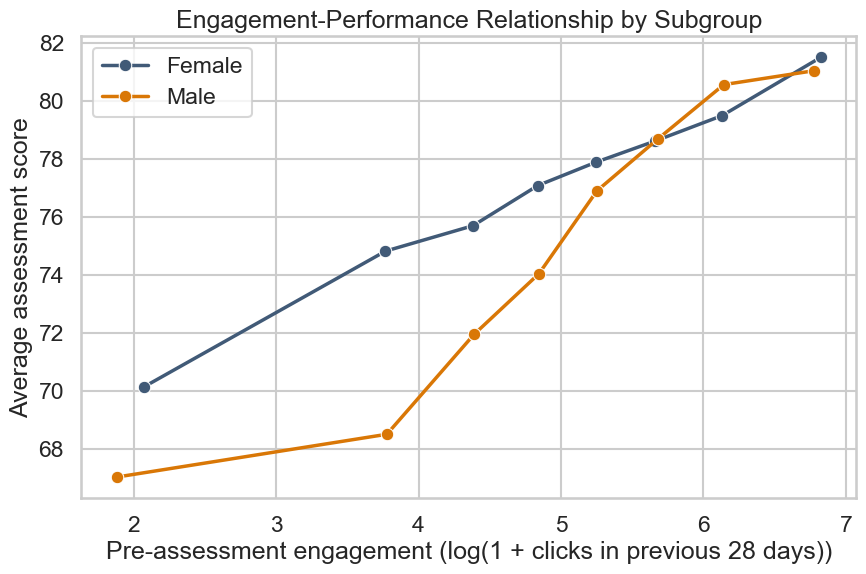

In [8]:
plot_click_distribution(panel)
plot_decile_relationship(panel)
plot_heterogeneity_relationship(panel)
plot_heterogeneity_relationship(
    panel, subgroup="is_female", subgroup_labels=("Male", "Female")
)

## Suggested Write-Up Structure

- One clear causal question.
- One clean panel dataset.
- One main fixed-effects model.
- Two or three robustness and subgroup analyses.
- A few clean figures that match the proposal.

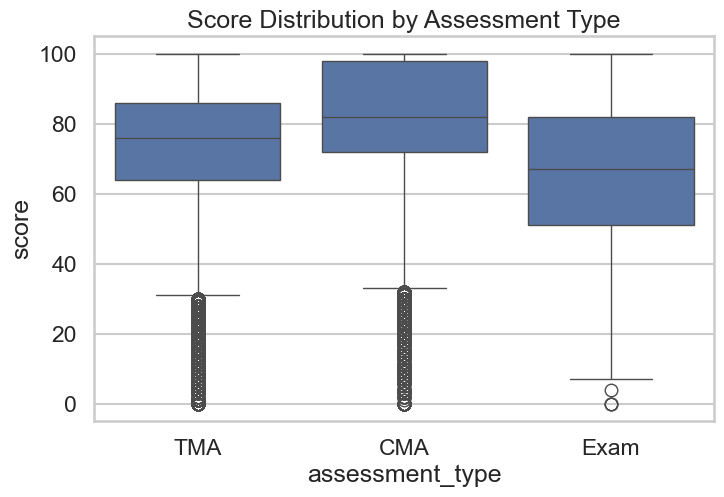

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.boxplot(data=panel, x='assessment_type', y='score')
plt.title('Score Distribution by Assessment Type')
plt.show()

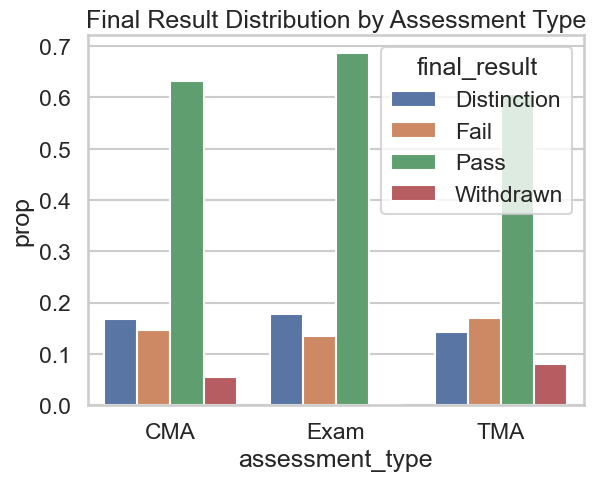

In [10]:
result_dist = (
    panel.groupby(['assessment_type', 'final_result'])
    .size()
    .reset_index(name='count')
)

result_dist['prop'] = result_dist.groupby('assessment_type')['count'].transform(lambda x: x / x.sum())

sns.barplot(data=result_dist, x='assessment_type', y='prop', hue='final_result')
plt.title('Final Result Distribution by Assessment Type')
plt.show()

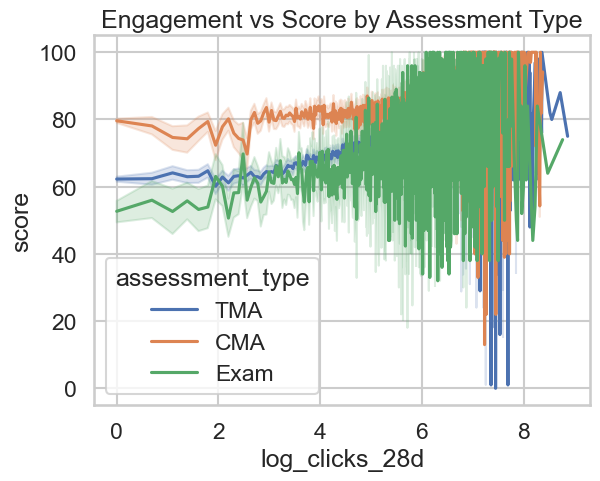

In [11]:
sns.lineplot(
    data=panel,
    x='log_clicks_28d',
    y='score',
    hue='assessment_type'
)
plt.title('Engagement vs Score by Assessment Type')
plt.show()

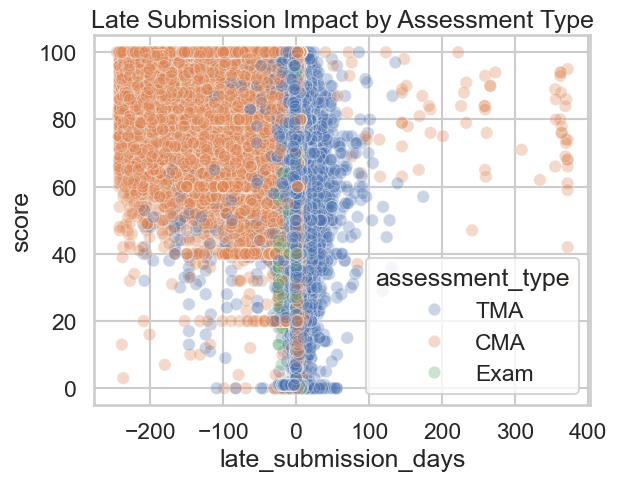

In [12]:
sns.scatterplot(
    data=panel,
    x='late_submission_days',
    y='score',
    hue='assessment_type',
    alpha=0.3
)
plt.title('Late Submission Impact by Assessment Type')
plt.show()